In [3]:
import os
import sys
sys.path.append(os.path.expanduser('~'))
import numpy as np 
from matplotlib import pyplot as plt
from datetime import datetime as dt
import figures as fgs
from albatros_analysis.src.correlations import baseband_data_classes as bdc
from albatros_analysis.src.utils import baseband_utils as butils
from albatros_analysis.src.utils import orbcomm_utils as outils
import numba as nb
import time
import importlib
import json
from scipy.optimize import minimize
from skyfield.api import load, wgs84
import cupy
import fitting_helper as fh

BDC is using numpy
BDC is using numpy


In [4]:
@nb.njit(parallel=True)
def apply_delay(arr, out, delay, freqs):
    # apply delay to an array of complex electric field or their correlation
    # does exp( j 2 pi nu tau) sign of tau is user dependent
    # freqs should correspond to the columns of the nspec x nchan array
    nspec = arr.shape[0]
    nchan = arr.shape[1]
    for i in nb.prange(nspec):
        for j in range(nchan):
            out[i, j] = arr[i, j] * np.exp(2j * np.pi * freqs[j] * delay[i])
    return out

@nb.njit(parallel=True)
def apply_delay_1d(arr, out, delay, freq):
    # apply delay to an array of complex electric field or their correlation
    # does exp( j 2 pi nu tau) sign of tau is user dependent
    # freqs should correspond to the columns of the nspec x nchan array
    nspec = arr.shape[0]
    for i in nb.prange(nspec):
            out[i] = arr[i] * np.exp(2j * np.pi * freq * delay[i])
    return out

@nb.njit(parallel=True)
def xcorr_avg(arr1,arr2,acclen):
    #helper function
    nblocks = arr1.shape[0]//acclen
    nchan = arr1.shape[1]
    out = np.zeros((nblocks,nchan),dtype=arr1.dtype)
    for i in nb.prange(nblocks):
        for j in range(acclen):
            for k in range(nchan):
                out[i,k] += arr1[i*acclen + j,k]*np.conj(arr2[i*acclen + j,k])
        out[i,:]/=acclen
    return out

@nb.njit(parallel=True)
def xcorr_avg_1d(arr1,arr2,acclen):
    #helper function
    nblocks = arr1.shape[0]//acclen
    out = np.zeros((nblocks,),dtype=arr1.dtype)
    for i in nb.prange(nblocks):
        for j in range(acclen):
                out[i] += arr1[i*acclen + j]*np.conj(arr2[i*acclen + j])
        out[i]/=acclen
    return out

In [5]:
config_path = '/home/thomasb/albatros_analysis/scripts/xcorr/config/config_bright_test.json'
disk_path = '/scratch/thomasb/raw_1753216650:1753217000_bit=1_ant=7_pol=2_cha=1834:1852_tim=650_upx=64_acc=512_ipfb=0.4_complex64_regular_20260110T114008.npy'

config_path2 = '/home/thomasb/albatros_analysis/scripts/xcorr/config/config_bright_test2.json'
disk_path2 = '/scratch/thomasb/raw_1753221865:1753222245_bit=1_ant=7_pol=2_cha=1834:1852_tim=706_upx=64_acc=512_ipfb=0.4_complex64_regular_20260106T105646.npy'

config_path3 = '/home/thomasb/albatros_analysis/scripts/xcorr/config/config_bright_test3.json'
disk_path3 = '/scratch/thomasb/raw_1753236330:1753236730_bit=1_ant=7_pol=2_cha=1834:1852_tim=744_upx=64_acc=512_ipfb=0.4_complex64_regular_20260106T220616.npy'

config_path4 = '/home/thomasb/albatros_analysis/scripts/xcorr/config/config_bright_test4.json'
disk_path4 = '/scratch/thomasb/raw_1753240805:1753241265_bit=1_ant=7_pol=2_cha=1834:1852_tim=856_upx=64_acc=512_ipfb=0.4_complex64_regular_20260107T190531.npy'

In [6]:
#open config and get metadata
with open(config_path, "r") as f:
    config = json.load(f)
ant_names, ant_coords, dir_parents, spec_offsets = [], [], [], []
# Call get_starting_index for all antennas except reference
for i, (ant, details) in enumerate(config["antennas"].items()):
    dir_parents.append(details["path"])
    spec_offsets.append(details["clock_offset"])
    ant_names.append(details["name"])
    ant_coords.append(details["coordinates"])

ant_numbers = np.array([int(name.split()[1]) for name in ant_names])
batch_start_ts = config["correlation"]["start_timestamp"]
batch_end_ts = config["correlation"]["end_timestamp"]
chanstart = config["frequency"]["start_channel"]
chanend = config["frequency"]["end_channel"]
osamp = config["correlation"]["osamp"]
pfb_size = config["correlation"]["pfb_size"]
new_acclen = config["correlation"]["new_acclen"]

new_chunk_len = (new_acclen*4096*osamp)/250e6
tle_path = outils.get_tle_file(batch_start_ts, "/project/rrg-sievers/mohanagr/OCOMM_TLES")

print(new_acclen)
print(batch_start_ts)
print(batch_end_ts)

512
1753216650
1753217000


In [8]:
#-----depends on pulse-------
#satID = 59051
satID = 57166
#satID = 25338

#first one
time_offset = -1.2524121093749998
#second one
#time_offset = 0.3371875
#third one
#time_offset = 0.53264453125
#fourth one
#time_offset = 1.166

In [9]:
ant_coords_new = np.array(ant_coords)
ant_coords_old = ant_coords_new.copy()
ant_coords_old[1] = [79.41721666666666, -90.75885, 176]

print(ant_coords_new[1])
print(ant_coords_old[1])

[ 79.41721848 -90.75872502 183.51076468]
[ 79.41721667 -90.75885    176.        ]


In [10]:
data_all = np.load(disk_path)
print(data_all.shape)

(7, 2, 332800, 1152)


In [11]:
acclen=1024
bb_spectrum_T = 4096/250e6
osamp = 64

T_SPECTRA = bb_spectrum_T * osamp
nchans = data_all.shape[3]
sat_freqs = 250e6 - ((np.arange(nchans)/osamp + 1834)/(4096/250e6))

print(nchans)
print(sat_freqs.shape)
print(sat_freqs[0])
print(T_SPECTRA)

1152
(1152,)
138061523.4375
0.001048576


331878
(7, 2, 331878, 300)
(349,)
(331878,)
perfoming beamformed cxcorr
assuming shape (nants, npols, nspec, nchans)
perfoming beamformed cxcorr
assuming shape (nants, npols, nspec, nchans)


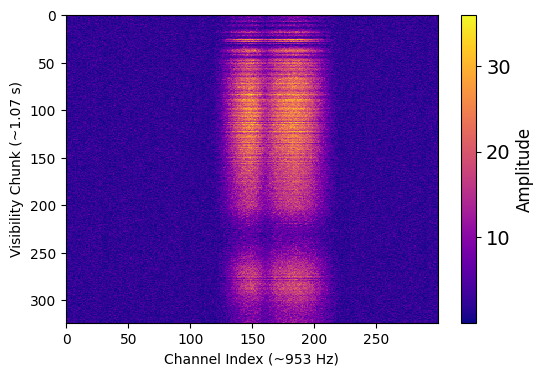

In [12]:
#check out the pulse vis
V = fh.efield_to_vis(data_all[:, :, :, :300], batch_start_ts, batch_end_ts-2, 0, 1, 0, 0, ant_coords, satID, sat_freqs[:300])
figure = fgs.make_ampfig(V, acclen, T_SPECTRA)

In [ ]:
#---------depends on pulse--------
#chan_new = 170
chan_new = 140
#chan_new = 460

cut_spectra_start = 60000

cut_seconds_end = 150
#--------------------------------

freq = sat_freqs[chan_new]
ant_idxs = [0, 2, 3, 4, 5, 6]

In [14]:
pulse_start_ts = batch_start_ts + T_SPECTRA*cut_spectra_start #cutting to part where SNR is high
pulse_end_ts = batch_end_ts - cut_seconds_end  #cutting when SNR gets low
data_cut = data_all[:, :, cut_spectra_start:, :]
data_slice_cut = data_all[:, :, cut_spectra_start:, chan_new]

In [19]:
print(pulse_start_ts)
print(pulse_end_ts)

1753216712.91456
1753216850


130734
(7, 2, 130734, 300)
(138,)
(130734,)
perfoming beamformed cxcorr
assuming shape (nants, npols, nspec, nchans)
perfoming beamformed cxcorr
assuming shape (nants, npols, nspec, nchans)


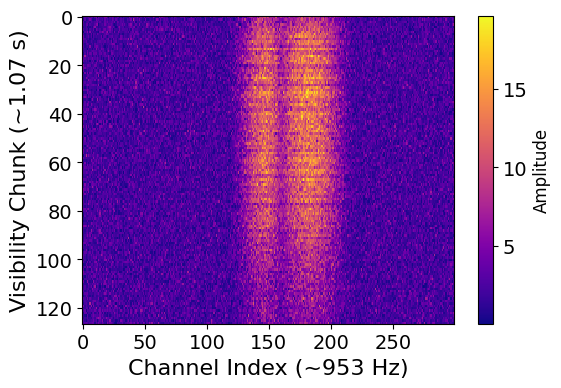

In [17]:
#check out the pulse vis
V = fh.efield_to_vis(data_cut[:, :, :, :300], pulse_start_ts, pulse_end_ts, 1, 2, 0, 0, ant_coords, satID, sat_freqs[:300])
figure = fgs.make_ampfig(V, acclen, T_SPECTRA)

In [15]:
def objective_coords(
    pos_offset,
    time_offset,
    t_start,
    t_end,
    data_slice,
    ant_idxs,
    fit_ant_idx, 
    ant_coords,
    freq,
    satID,
    plot=False,
    bb_spectrum_T=4096/250e6,
    osamp=64,
    acclen = 1024
    ):

    """
    Gives chi squared given some antenna coordinates and a timing discrepancy

    t_start needs to coincide with the first spectrum of the data.
    however, t_end will determine how much the data is cut by, so as long as it's
    BEFORE the last spectrum in the data, we're all good.

    this is done to make cutting garbage time at the end easier, and minimize interference with the data array
    """
    print(pos_offset)

    if plot:
        fig, ax = plt.subplots(figsize=(10, 5), dpi=300)
        plt.axhline(6.28, ls='--',c='black')
        plt.axhline(-6.28,ls='--', c='black')
        plt.rcParams.update({
            "font.size": 16,
            "axes.labelsize": 18,
            "axes.titlesize": 20,
            "xtick.labelsize": 14,
            "ytick.labelsize": 14,
            "figure.titlesize": 22,
            "legend.fontsize": 14
        })

    process_start_ts = time.time()

    a1_coords = ant_coords[fit_ant_idx]
    T_SPECTRA = bb_spectrum_T * osamp
    tle_path = outils.get_tle_file(t_start, "/project/rrg-sievers/mohanagr/OCOMM_TLES")
    sats_objects = load.tle_file(tle_path)
    
    nspec_tot = data_slice.shape[2]
    nspec = int((t_end-t_start)/T_SPECTRA)
    print('nspec total', nspec_tot)
    print('nspec', nspec)
    data_slice = data_slice[:, :, :nspec].copy()

    assert nspec_tot > nspec
    assert (nspec*bb_spectrum_T) < (t_end-t_start+1)
    
    chisq = 0
    sum_wt = 0

    for j in range(len(ant_idxs)):
        nonfit_ant_idx = ant_idxs[j]
        a2_coords = ant_coords[nonfit_ant_idx]
        dist = oh.haversine(a1_coords, a2_coords)
        sum_wt += dist


        dly = outils.get_sat_delay2(
                            [a1_coords[0]+1e-4*pos_offset[0], a1_coords[1]+1e-4*pos_offset[1], a1_coords[2]+pos_offset[2]],
                            a2_coords,
                            sats_objects,
                            t_start+time_offset,
                            int(t_end-t_start)+1,
                            satID,
                            altaz=False
                        )

        delay = np.interp(
            np.arange(0, nspec) * T_SPECTRA, np.arange(0, int(t_end-t_start)+1), dly
        )

        spec2_phased = np.empty_like(data_slice[nonfit_ant_idx, 0, :])
        spec2_phased = apply_delay_1d(data_slice[nonfit_ant_idx, 0, :], spec2_phased, -delay, freq)
        Vxx = xcorr_avg_1d(data_slice[fit_ant_idx,0,:], spec2_phased, acclen)
        spec2_phased = apply_delay_1d(data_slice[nonfit_ant_idx, 1, :], spec2_phased, -delay, freq)
        Vyy = xcorr_avg_1d(data_slice[fit_ant_idx,1,:], spec2_phased, acclen)
        V=(Vxx+Vyy)/2


        if plot:
            ax.plot(np.unwrap(np.angle(V))-np.angle(V)[0],label=f'{fit_ant_idx}-{nonfit_ant_idx}')
            plt.legend()

        Vnew = np.exp(1j*np.angle(V))
        chisq-= dist * np.abs(np.mean(Vnew))**2 #cut it off where snr drops
    chisq/=sum_wt
    print('time for objective compute:', time.time()-process_start_ts)

    if plot:
        ax.set_xlabel(f"Visibility Chunk(~{np.round(T_SPECTRA*acclen, decimals=2)} s)")
        ax.set_ylabel("Unwrapped Phase (radians)")
        ax.set_title(f"Phase at Baslines (offset={time_offset}, sat={satID})")
        ax.grid(True, alpha=0.3)

        ax.legend(
            loc="center left",
            bbox_to_anchor=(1.02, 0.5),
            frameon=False
        )

    plt.tight_layout()
    print("chisq", chisq)
    return chisq

[0, 0, 0]
nspec total 272800
nspec 130734
time for objective compute: 0.9970829486846924
chisq -0.08554324340461436


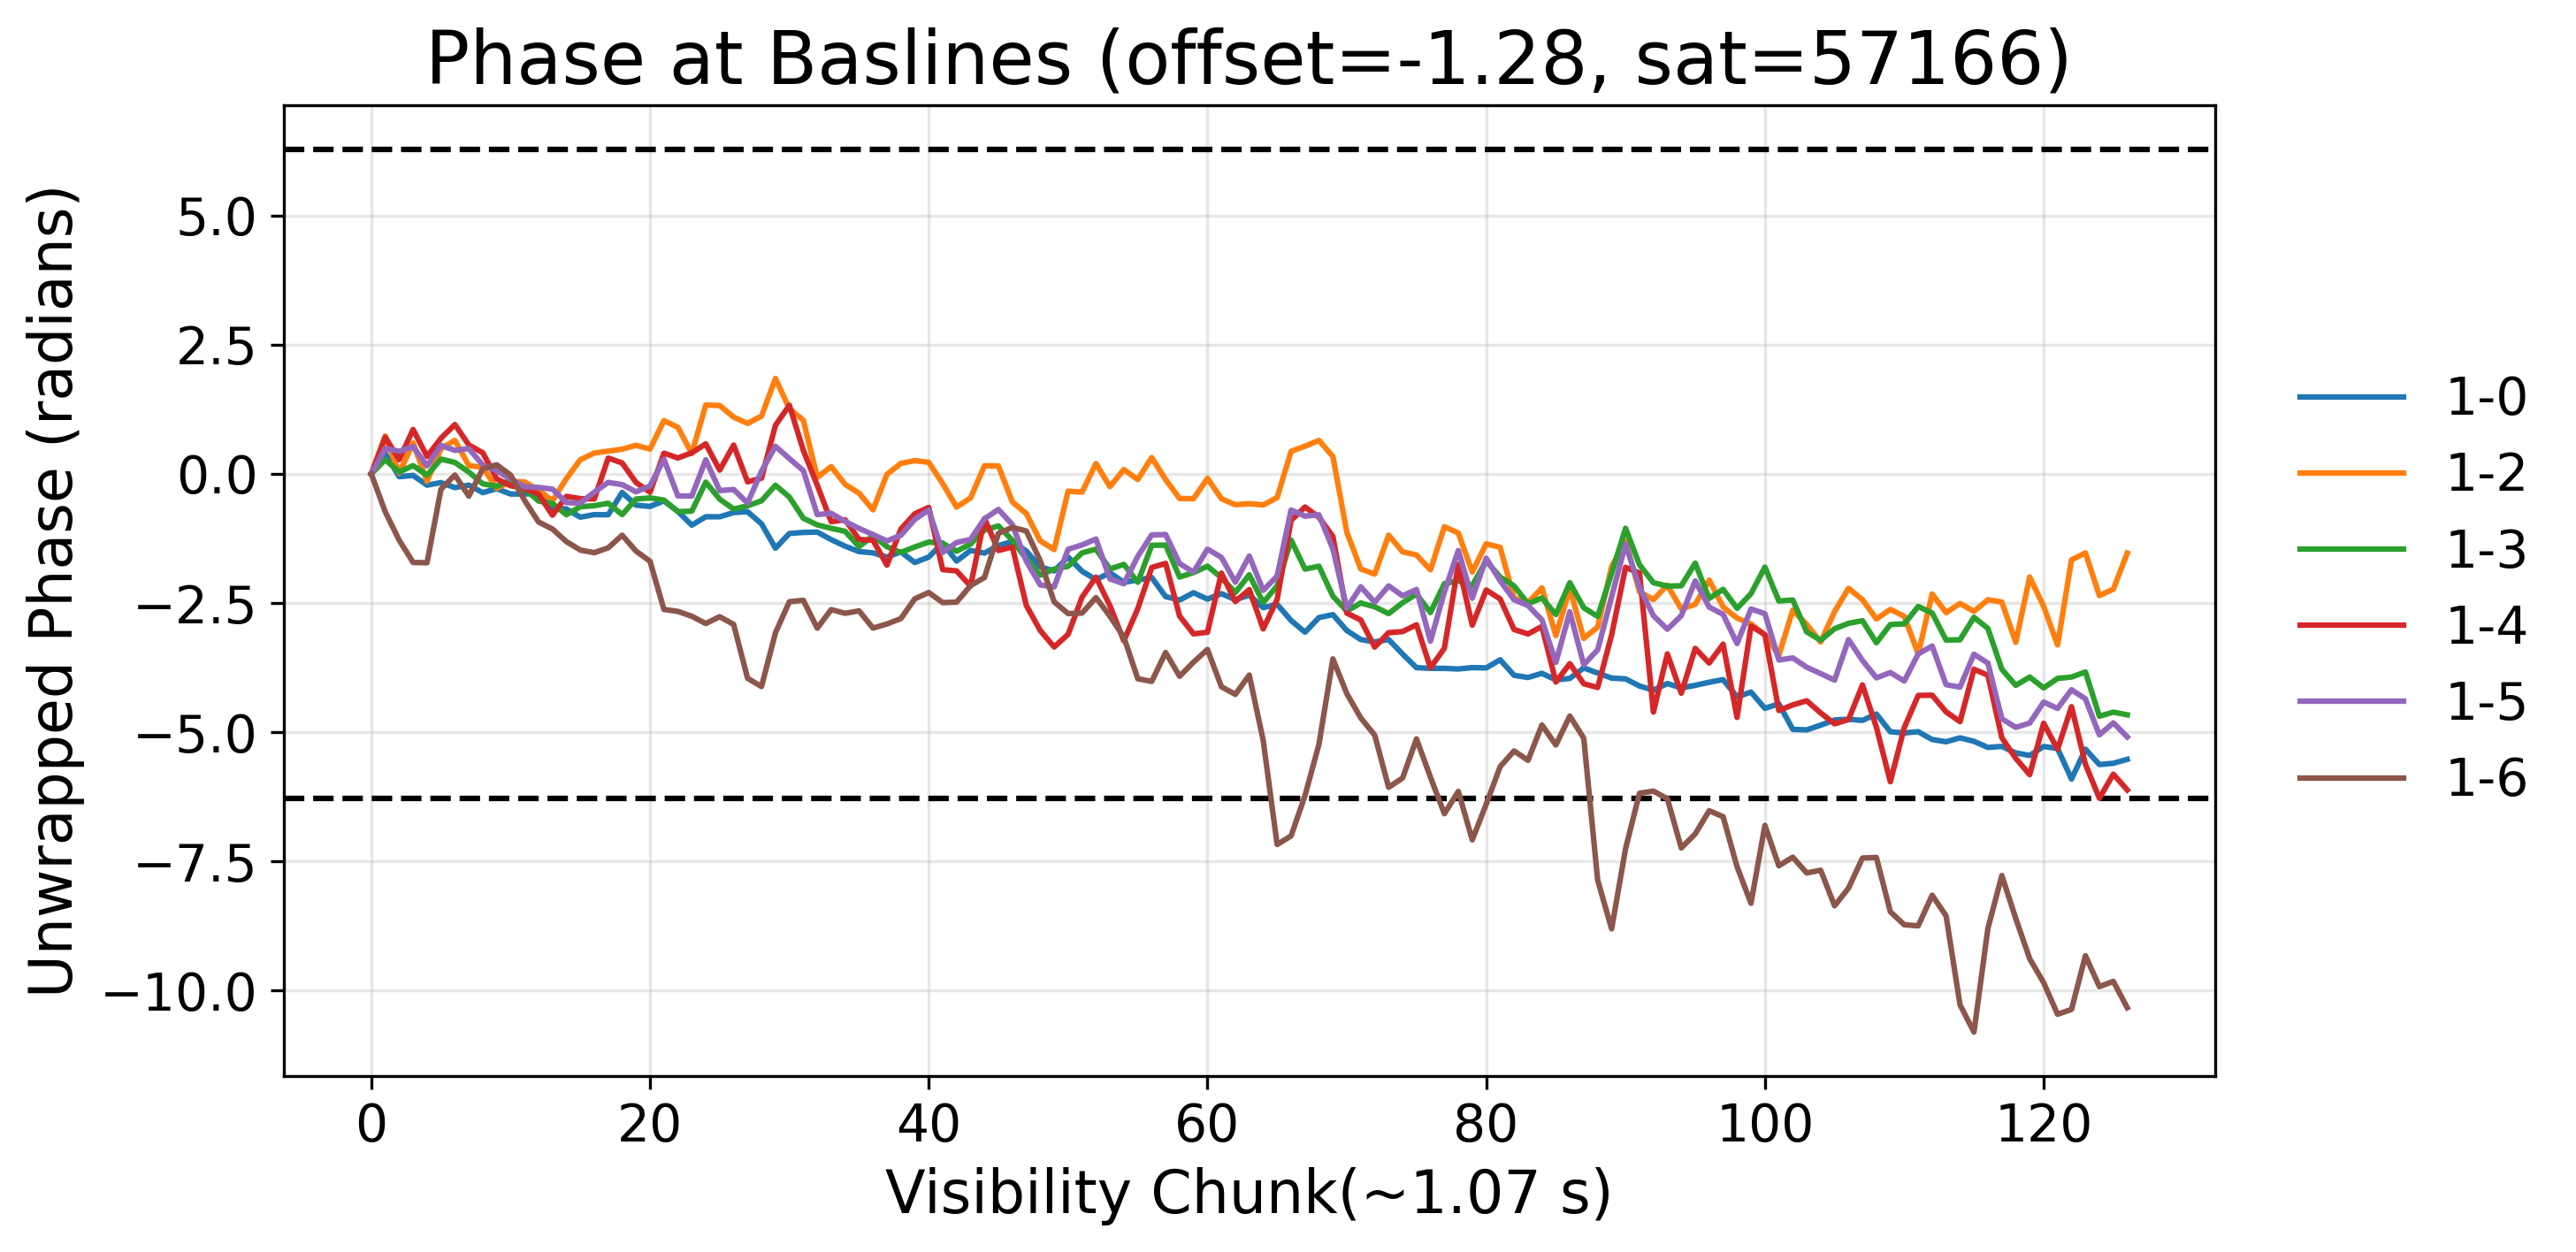

In [16]:
#with the old coordinates, right time offset
chisq = objective_coords(
        [0, 0, 0],
        time_offset,
        pulse_start_ts,
        pulse_end_ts,
        data_slice_cut,
        ant_idxs,
        1, 
        ant_coords_old,
        freq,
        satID,
        plot=True
        )


[0, 0, 0]
nspec total 272800
nspec 130734
time for objective compute: 0.3397860527038574
chisq -0.4178696221629279


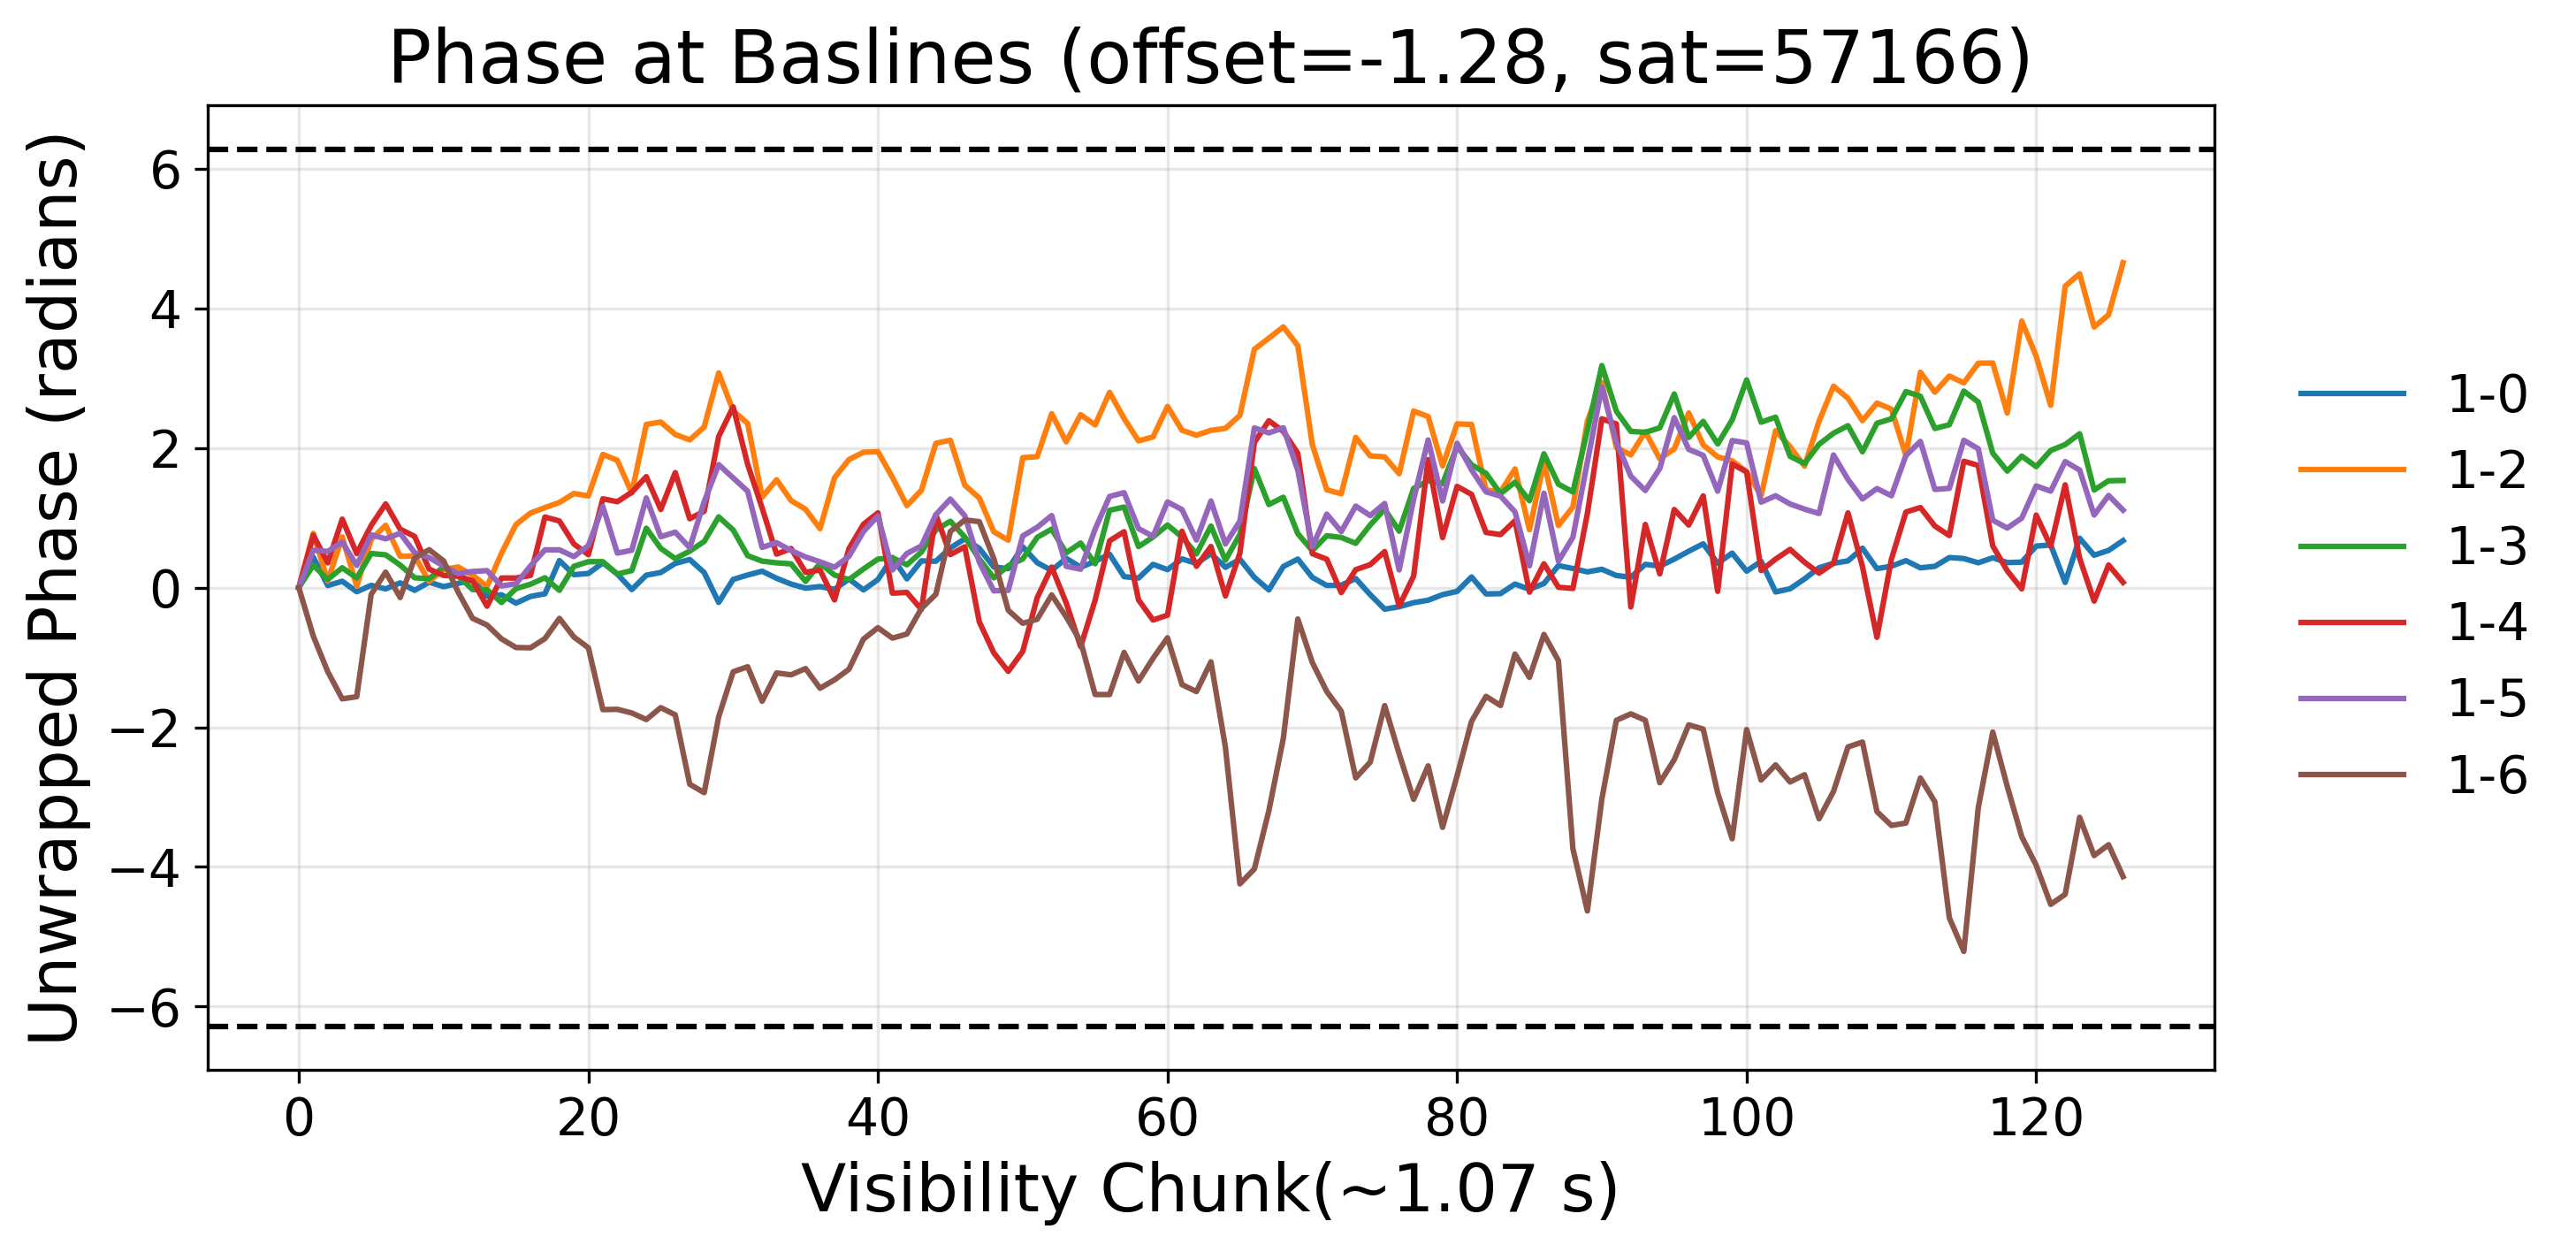

In [17]:
#with the new coordinates, right time offset
chisq = objective_coords(
    [0, 0, 0],
    time_offset,
    pulse_start_ts,
    pulse_end_ts,
    data_slice_cut,
    ant_idxs,
    1, 
    ant_coords_new,
    freq,
    satID,
    plot=True
    )


In [18]:
def cost_curve(
    lats,
    lons,
    alt_offset,
    time_offset,
    t_start,
    t_end,
    data_slice,
    ant_idxs,
    fit_ant_idx,
    ant_coords,
    freq,
    satID,
    bb_spectrum_T=4096/250e6,
    osamp=64,
    include_fig=False
):

    assert len(lons) == len(lats)
    nstep = len(lons)
    #lats = np.linspace(lats[0], lats[1], nstep)
    #lons = np.linspace(lons[0], lons[1], nstep)
    chisqs = np.zeros((nstep, nstep) ,dtype='float64')

    for i, lon in enumerate(lats):
        for j, lat in enumerate(lons):
            print(f'\n----ITERATION {j, i}-----')
            chisqs[i, j]=objective_coords(
                                [lat, lon, alt_offset],
                                time_offset,
                                t_start,
                                t_end,
                                data_slice,
                                ant_idxs,
                                fit_ant_idx, 
                                ant_coords,
                                freq,
                                satID,
                                plot=False
            )
    
    if include_fig:
        fig, ax = plt.subplots()
        im = ax.imshow(
            chisqs,
            origin='lower',
            aspect='auto',
            cmap='viridis',
            extent=[lats[0], lats[-1], lons[0], lons[-1]]  
        )
        plt.rcParams.update({
                    "font.size": 16,
                    "axes.labelsize": 18,
                    "axes.titlesize": 20,
                    "xtick.labelsize": 14,
                    "ytick.labelsize": 14,
                    "figure.titlesize": 22,
                    "legend.fontsize": 14
                })
        ax.set_xlabel('Lat Offset ()')
        ax.set_ylabel('Lon Offset ()')
        cbar = fig.colorbar(im, ax=ax)
        cbar.set_label(r'$\chi^2$')
        ax.plot(
            0, 0,
            marker='x',
            color='red',
            markersize=10,
            markeredgewidth=2)
        plt.tight_layout()
        return chisqs, fig
    else:
        return chisqs

In [42]:
nstep = 51
lats = np.linspace(-5, 5, nstep)
lons = np.linspace(-5, 5, nstep)
#print(lats)
#print(lons)


----ITERATION (0, 0)-----
[np.float64(-5.0), np.float64(-5.0), 0]
nspec total 380928
nspec 380516
time for objective compute: 0.45235514640808105
chisq -0.0013390780141410057

----ITERATION (1, 0)-----
[np.float64(-4.8), np.float64(-5.0), 0]
nspec total 380928
nspec 380516
time for objective compute: 0.45792055130004883
chisq -0.0036952261989118516

----ITERATION (2, 0)-----
[np.float64(-4.6), np.float64(-5.0), 0]
nspec total 380928
nspec 380516
time for objective compute: 0.47913098335266113
chisq -0.0025560488071650466

----ITERATION (3, 0)-----
[np.float64(-4.4), np.float64(-5.0), 0]
nspec total 380928
nspec 380516
time for objective compute: 0.456911563873291
chisq -0.005718367245790403

----ITERATION (4, 0)-----
[np.float64(-4.2), np.float64(-5.0), 0]
nspec total 380928
nspec 380516
time for objective compute: 0.432466983795166
chisq -0.003605221765891055

----ITERATION (5, 0)-----
[np.float64(-4.0), np.float64(-5.0), 0]
nspec total 380928
nspec 380516
time for objective compute:

<Figure size 640x480 with 0 Axes>

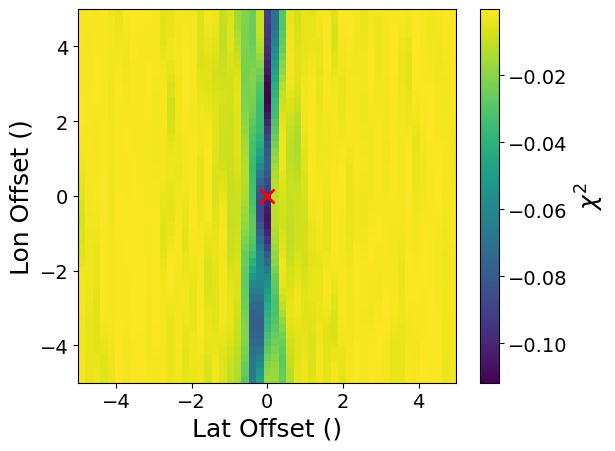

: 

In [ ]:
#using new coordinates. should see very low chisq near center as sanity check
chisqs, fig = cost_curve(
                    lats,
                    lons,
                    0,
                    time_offset,
                    pulse_start_ts,
                    pulse_end_ts,
                    data_slice_cut,
                    ant_idxs,
                    1,
                    ant_coords_new,
                    freq,
                    satID,
                    include_fig=True
                    )

In [79]:
lat_offset = 1
lon_offset = 0
alt_offset = 0

a1_coords = ant_coords[0]
a2_coords = ant_coords[1]
a2_coords_shift = a2_coords + np.array([lat_offset * 1e-4, lon_offset * 1e-4, alt_offset])

dist_original = haversine(a1_coords, a2_coords)
dis_shifted = haversine(a1_coords, a2_coords_shift)
print(abs(dist_original - dis_shifted))

0.6324850044218806


In [ ]:
row, col = np.unravel_index(np.argmin(chisqs), chisqs.shape)
print(np.min(chisqs))
print(row, col)
print(chisqs[row, col])
guess_offset = np.array([lats[row], lons[col], 0]) #make sure this doesn't get confused
print(guess_offset)

-0.4978313227654792
27 24
-0.4978313227654792
[ 0.8 -0.4  0. ]
